# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [15]:
!pip install groq feedparser -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.4 MB/s eta 0:00:00


In [16]:
# TakeMeter — Data Collection + Pre-labeling Script
# Run this in Google Colab (or locally with Python 3)
#
# What it does:
#   1. Fetches posts from r/contentcreation and r/ContentCreators via Reddit RSS feeds
#      (no API key or account required)
#   2. Filters out question/help posts that don't fit the label taxonomy
#   3. Pre-labels each post using Groq (llama-3.3-70b-versatile) with your label definitions
#   4. Saves everything to a CSV: text, label, notes, subreddit, url
#
# YOU MUST review and correct every label before using the CSV for training.
# Skim-reviewing defeats the purpose and produces noisy training data.

# ─── INSTALL DEPENDENCIES ─────────────────────────────────────────────────────
# Uncomment and run this cell first if in Colab:
# !pip install groq feedparser -q

import feedparser
import requests
import time
import csv
import re
from html import unescape
from groq import Groq

# ─── CONFIG ───────────────────────────────────────────────────────────────────
# To use Colab Secrets instead:
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")


SUBREDDITS = ["contentcreation", "ContentCreators", "creators", "NewTubers"]
OUTPUT_FILE = "takemeter_prelabeled.csv"

# RSS feed sorts + time windows — pulls from multiple to maximise post count
RSS_FEEDS = [
    ("top", "?t=month"),
    ("top", "?t=year"),
    ("top", "?t=all"),
    ("hot", ""),
    ("new", ""),
]

DELAY_BETWEEN_REQUESTS = 4  # seconds — avoids 429 rate limiting

# Keywords that suggest a post is a question/help request — skip these
SKIP_PATTERNS = [
    "how do i", "how to", "any tips", "any advice", "help me", "need help",
    "i need help", "where can i", "what should i", "should i", "can someone",
    "looking for", "recommendations", "suggest", "advice needed", "advice for",
    "how can i", "help!", "??", "???",
]

# ─── LABEL DEFINITIONS (used in the Groq prompt) ──────────────────────────────

LABEL_DEFINITIONS = """
You are a text classifier for an online content creator community. Classify each post into exactly one of these three labels:

analysis — the post makes a structured argument about content creation strategy, platform behavior, or the industry, with specific reasoning or evidence. The point could stand on its own even without the author's personal feelings.

hot_take — a bold, confident opinion about content creation stated with little or no supporting argument. The claim might be true, but the post asserts rather than reasons.

experience — a personal story or account from someone's creator journey. The post is primarily about what happened to them, not making a general argument.

Decision rule for edge cases: if a post shares a personal story AND makes a broader argument, ask what the PRIMARY purpose is. If it's mostly storytelling → experience. If it's mostly arguing a general point → analysis.

Respond with ONLY one word: analysis, hot_take, or experience. No explanation.
"""

# ─── FETCH POSTS VIA RSS ──────────────────────────────────────────────────────

def clean_html(text):
    """Strip HTML tags and unescape HTML entities."""
    text = re.sub(r"<[^>]+>", " ", text)
    text = unescape(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def fetch_via_rss(subreddit, sort="top", params=""):
    """Fetch posts from a subreddit using its public RSS feed."""
    url = f"https://www.reddit.com/r/{subreddit}/{sort}/.rss{params}&limit=100"
    headers = {"User-Agent": "TakeMeter/1.0 (academic NLP project)"}

    try:
        response = requests.get(url, headers=headers, timeout=15)
        if response.status_code == 429:
            print(f"    Rate limited (429) — waiting 10s before continuing...")
            time.sleep(10)
            return []
        if response.status_code != 200:
            print(f"    r/{subreddit} {sort}{params} returned {response.status_code}")
            return []

        feed = feedparser.parse(response.text)
        posts = []

        for entry in feed.entries:
            title = entry.get("title", "").strip()
            summary = clean_html(entry.get("summary", ""))
            link = entry.get("link", "")

            if summary and len(summary) > len(title) + 20:
                full_text = f"{title}\n\n{summary[:1500]}"
            else:
                full_text = title

            posts.append({
                "title": title,
                "text": full_text,
                "subreddit": subreddit,
                "url": link,
            })

        return posts

    except Exception as e:
        print(f"    Error: {e}")
        return []


def is_question_post(title):
    """Return True if the post looks like a question/help request."""
    title_lower = title.lower()
    for pattern in SKIP_PATTERNS:
        if pattern in title_lower:
            return True
    # Also skip very short titles (likely low-content posts)
    if len(title.split()) < 4:
        return True
    return False

def fetch_all_posts(subreddits, feeds):
    """Fetch posts from all subreddits and feed combos, deduplicate by title."""
    all_posts = []
    seen_titles = set()

    for subreddit in subreddits:
        for sort, params in feeds:
            label = f"{sort}{params}" if params else sort
            print(f"  r/{subreddit} ({label})...")
            posts = fetch_via_rss(subreddit, sort, params)
            new = 0
            for p in posts:
                if p["title"] not in seen_titles:
                    seen_titles.add(p["title"])
                    all_posts.append(p)
                    new += 1
            print(f"    +{new} new posts (total: {len(all_posts)})")
            time.sleep(DELAY_BETWEEN_REQUESTS)

    return all_posts


# ─── PRE-LABEL WITH GROQ ──────────────────────────────────────────────────────

def prelabel_post(client, text):
    """Send a post to Groq and get back a label."""
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": LABEL_DEFINITIONS},
                {"role": "user", "content": f"Post:\n{text[:1000]}"},  # cap at 1000 chars
            ],
            max_tokens=10,
            temperature=0,
        )
        label = response.choices[0].message.content.strip().lower()

        # Validate — if the model returns something unexpected, mark for review
        if label not in ["analysis", "hot_take", "experience"]:
            return "REVIEW_NEEDED"
        return label

    except Exception as e:
        print(f"  Groq error: {e}")
        return "REVIEW_NEEDED"


# ─── MAIN ─────────────────────────────────────────────────────────────────────

def main():
    if not GROQ_API_KEY:
        print("ERROR: Set your GROQ_API_KEY at the top of the script.")
        return

    client = Groq(api_key=GROQ_API_KEY)

    print("Fetching posts from Reddit RSS feeds (no API key needed)...")
    print("Note: 4s delay between requests to avoid rate limiting — this takes ~5 min\n")
    all_posts = fetch_all_posts(SUBREDDITS, RSS_FEEDS)
    print(f"\nTotal unique posts fetched: {len(all_posts)}")

    # Filter out question/help posts
    filtered = [p for p in all_posts if not is_question_post(p["title"])]
    print(f"After filtering question posts: {len(filtered)} remaining")

    if len(filtered) < 50:
        print("\nWARNING: Fewer than 50 posts after filtering.")
        print("RSS feeds may be rate-limiting. Try running again in a few minutes.")
        return

    # Pre-label with Groq
    print(f"\nPre-labeling {len(filtered)} posts with Groq...")
    results = []
    for i, post in enumerate(filtered):
        label = prelabel_post(client, post["text"])
        results.append({
            "text": post["text"],
            "label": label,   # AI PRE-LABEL — YOU MUST REVIEW EVERY ONE
            "notes": "",      # Add your notes here during review
            "subreddit": post["subreddit"],
            "url": post["url"],
        })
        if (i + 1) % 20 == 0:
            print(f"  Labeled {i + 1}/{len(filtered)}...")
        time.sleep(0.3)

    # Save to CSV
    with open(OUTPUT_FILE, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["text", "label", "notes", "subreddit", "url"])
        writer.writeheader()
        writer.writerows(results)

    print(f"\nDone! Saved {len(results)} posts to '{OUTPUT_FILE}'")

    # Print label distribution
    from collections import Counter
    dist = Counter(r["label"] for r in results)
    print("\nLabel distribution (AI pre-labels — review before trusting):")
    for label, count in sorted(dist.items()):
        pct = count / len(results) * 100
        print(f"  {label}: {count} ({pct:.0f}%)")

    if max(dist.values()) / len(results) > 0.70:
        print("\nWARNING: One label is over 70% of the dataset.")
        print("After reviewing, balance your dataset before training.")

    print("\n*** IMPORTANT: Open the CSV and read every post. ***")
    print("*** Fix any wrong labels in the 'label' column. ***")
    print("*** Note hard edge cases in the 'notes' column.  ***")


if __name__ == "__main__":
    main()


Fetching posts from Reddit RSS feeds (no API key needed)...
Note: 4s delay between requests to avoid rate limiting — this takes ~5 min

  r/contentcreation (top?t=month)...
    +99 new posts (total: 99)
  r/contentcreation (top?t=year)...
    Rate limited (429) — waiting 10s before continuing...
    +0 new posts (total: 99)
  r/contentcreation (top?t=all)...
    Rate limited (429) — waiting 10s before continuing...
    +0 new posts (total: 99)
  r/contentcreation (hot)...
    r/contentcreation hot returned 403
    +0 new posts (total: 99)
  r/contentcreation (new)...
    r/contentcreation new returned 403
    +0 new posts (total: 99)
  r/ContentCreators (top?t=month)...
    Rate limited (429) — waiting 10s before continuing...
    +0 new posts (total: 99)
  r/ContentCreators (top?t=year)...
    +99 new posts (total: 198)
  r/ContentCreators (top?t=all)...
    Rate limited (429) — waiting 10s before continuing...
    +0 new posts (total: 198)
  r/ContentCreators (hot)...
    r/ContentCr

In [17]:
# RESUME LABELING — run this after the main script hits token limits
# It reads your existing CSV and re-labels only the REVIEW_NEEDED rows

import csv, time
from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")
client = Groq(api_key=GROQ_API_KEY)

LABEL_DEFINITIONS = """
You are a text classifier. Classify each post into exactly one label:
analysis — structured argument with specific reasoning or evidence
hot_take — bold opinion stated with little or no supporting argument
experience — personal story about someone's creator journey

Reply with ONE word only: analysis, hot_take, or experience
"""

INPUT_FILE = "takemeter_prelabeled.csv"
OUTPUT_FILE = "takemeter_prelabeled.csv"

# Read existing CSV
with open(INPUT_FILE, newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

print(f"Total rows: {len(rows)}")
print(f"REVIEW_NEEDED: {sum(1 for r in rows if r['label'] == 'REVIEW_NEEDED')}")

# Re-label only REVIEW_NEEDED rows
fixed = 0
for i, row in enumerate(rows):
    if row["label"] != "REVIEW_NEEDED":
        continue
    try:
        # Truncate aggressively to save tokens
        text = row["text"][:300]
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",  # higher token limits than 70b
            messages=[
                {"role": "system", "content": LABEL_DEFINITIONS},
                {"role": "user", "content": text},
            ],
            max_tokens=5,
            temperature=0,
        )
        label = response.choices[0].message.content.strip().lower()
        if label not in ["analysis", "hot_take", "experience"]:
            label = "REVIEW_NEEDED"
        row["label"] = label
        fixed += 1
    except Exception as e:
        print(f"  Error on row {i}: {e}")
        break  # stop if we hit limits again, resume later
    time.sleep(0.2)
    if fixed % 50 == 0:
        print(f"  Fixed {fixed} rows...")

# Save back
with open(OUTPUT_FILE, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

from collections import Counter
dist = Counter(r["label"] for r in rows)
print(f"\nSaved. Label distribution:")
for label, count in sorted(dist.items()):
    print(f"  {label}: {count} ({count/len(rows)*100:.0f}%)")

Total rows: 249
REVIEW_NEEDED: 0

Saved. Label distribution:
  analysis: 120 (48%)
  experience: 119 (48%)
  hot_take: 10 (4%)


In [18]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [19]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [20]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "analysis":  0,
    "hot_take":  1,
    "experience":  2,
}
# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'analysis': 0, 'hot_take': 1, 'experience': 2}
Number of labels: 3


In [21]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving takemeter_dataset.csv to takemeter_dataset (2).csv
Uploaded: takemeter_dataset (2).csv


In [22]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'notes', 'subreddit', 'url']
Total examples: 332

Label distribution:
label
experience    157
analysis      103
hot_take       72
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [23]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 232 examples
Validation: 50 examples
Test: 50 examples

Train label distribution:
label
experience    110
analysis       72
hot_take       50
Name: count, dtype: int64

Test label distribution:
label
experience    23
analysis      16
hot_take      11
Name: count, dtype: int64


In [24]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/232 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [34]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [35]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [36]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.085717,1.058023,0.480000
2,1.040428,1.008125,0.480000
3,1.006967,0.941870,0.520000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [37]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.560

Per-class metrics (fine-tuned model):
              precision    recall  f1-score   support

    analysis       0.83      0.31      0.45        16
    hot_take       0.00      0.00      0.00        11
  experience       0.52      1.00      0.69        23

    accuracy                           0.56        50
   macro avg       0.45      0.44      0.38        50
weighted avg       0.51      0.56      0.46        50



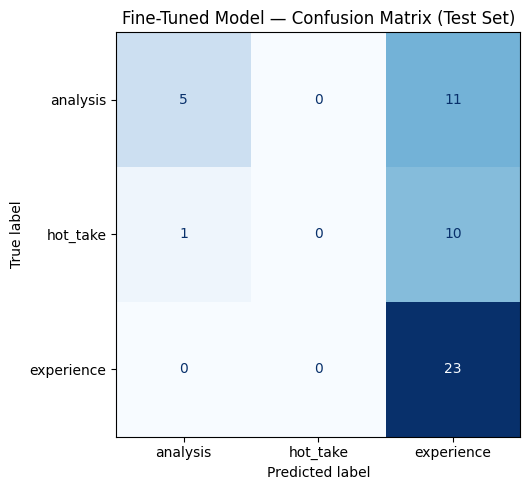

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [38]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [39]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 22 / 50

--- #1 ---
Text:      Are some of you interested in Interviews in general? We mostly interview TV/Movie Stars and Game Developers. If you like that stuff or video game gameplay, a sub would help a lot.
True:      hot_take
Predicted: experience  (confidence: 0.41)

--- #2 ---
Text:      Never doing critiques again

I've been part of this community for a long time and really enjoy giving and receiving feedback here. Earlier this week I offered to give feedback and watched over 50 of y...
True:      hot_take
Predicted: experience  (confidence: 0.56)

--- #3 ---
Text:      I Analyzed 116 Small Gaming YouTubers, Here's What You're Doing Wrong:

A few days ago I made a post asking you guys to send me your gaming videos, and in the past 3 days I've spent around 20 hours lo...
True:      analysis
Predicted: experience  (confidence: 0.50)

--- #4 ---
Text:      Side Income Opportunity Using Your Social Media Account ($100-$500)

Hi guys if you want to earn a good amo

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [26]:
!pip install groq -q

In [27]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [28]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are a text classifier for an online content creator community.
Classify each post into exactly one of these three labels:

analysis — the post makes a structured argument about content creation strategy,
platform behavior, or the industry, with specific reasoning or evidence.

hot_take — a bold, confident opinion about content creation stated with little
or no supporting argument. The claim might be true, but the post asserts rather
than reasons.

experience — a personal story or account from someone's creator journey.
The post is primarily about what happened to them, not making a general argument.

Respond with ONLY one word: analysis, hot_take, or experience. No explanation.
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 692 characters


In [30]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.1-8b-instant",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prombpt — the model may not be outputting clean label names.")

Running baseline on 50 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/50 complete...
  20/50 complete...
  30/50 complete...
  40/50 complete...
  50/50 complete...


In [32]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.600  (evaluated on 50/50 parseable responses)

Per-class metrics (baseline):
              precision    recall  f1-score   support

    analysis       0.60      0.56      0.58        16
    hot_take       1.00      0.27      0.43        11
  experience       0.56      0.78      0.65        23

    accuracy                           0.60        50
   macro avg       0.72      0.54      0.55        50
weighted avg       0.67      0.60      0.58        50



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [40]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.600
Fine-tuned DistilBERT                  0.560
---------------------------------------------

Fine-tuning regression: 0.040

Use these numbers in your README evaluation report.


In [41]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download
